## Preliminary Data Exploration

In [55]:
import pandas as pd

In [56]:
# Load the dataset
df = pd.read_csv('./data/student_records.csv')
df.head()

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,NaN,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  str    
 3   CCA                 12071 non-null  str    
 4   learning_style      15900 non-null  str    
 5   student_id          15900 non-null  str    
 6   gender              15900 non-null  str    
 7   tuition             15900 non-null  str    
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  str    
 15  wake_time           15900 non-null  str    
 16  mode_of_transpo

Three columns stand out with missing data: `CCA`, `final_test`, and `attendance_rate` show fewer non-null entries than the rest.

In [58]:
# Check for missing values
df.isna().sum()

index                    0
number_of_siblings       0
direct_admission         0
CCA                   3829
learning_style           0
student_id               0
gender                   0
tuition                  0
final_test             495
n_male                   0
n_female                 0
age                      0
hours_per_week           0
attendance_rate        778
sleep_time               0
wake_time                0
mode_of_transport        0
bag_color                0
dtype: int64

`CCA` is missing 3,829 values, `final_test` is missing 495, and `attendance_rate` is missing 778.

In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,15900.0,7949.500000,4590.078975,0.0,3974.75,7949.5,11924.25,15899.0
number_of_siblings,15900.0,0.886541,0.751346,0.0,0.00,1.0,1.00,2.0
final_test,15405.0,67.165401,13.977879,32.0,56.00,68.0,78.00,100.0
n_male,15900.0,13.880000,6.552584,0.0,10.00,14.0,18.00,31.0
n_female,15900.0,8.906038,6.663852,0.0,4.00,8.0,13.00,31.0
age,15900.0,15.213459,1.758941,-5.0,15.00,15.0,16.00,16.0
hours_per_week,15900.0,10.312579,4.461861,0.0,7.00,9.0,14.00,20.0
attendance_rate,15122.0,93.270268,7.984230,40.0,92.00,95.0,97.00,100.0


`.describe()` shows that `age` contains values that are not valid for students taking O-level Mathematics, where the expected age is 15 or 16. Before fixing them, I first counted how many records are affected.

In [60]:
# Count invalid ages
invalid_age = ~df['age'].isin([15, 16])
print('Number of invalid ages:', invalid_age.sum())
df.loc[invalid_age, 'age'].value_counts()

Number of invalid ages: 451


age
 6.0    230
 5.0    216
-5.0      4
-4.0      1
Name: count, dtype: int64

There are 451 records with invalid ages: 230 with age 6, 216 with age 5, 4 with age -5 and 1 with age -4.

Ages 5 and 6 were assumed to be data entry errors with the leading "1" left out, and were corrected to 15 and 16. As the correct values for the negative ages cannot be determined, they were imputed with the mode of the valid ages, which is 16.

In [61]:
# Fix data entry errors
df['age'] = df['age'].replace({5: 15, 6: 16})

# Impute negative ages with the mode of valid ages
mode_age = df.loc[df['age'] > 0, 'age'].mode()[0]
df.loc[df['age'] < 0, 'age'] = mode_age

# Verify the changes
df['age'].value_counts()

age
16.0    7958
15.0    7942
Name: count, dtype: int64

In [62]:
# Check for duplicate student records
print('Duplicate student_id rows:', df['student_id'].duplicated().sum())

# Show duplicate records next to each other to compare them
df[df['student_id'].duplicated(keep=False)].sort_values(by='student_id')

Duplicate student_id rows: 900


,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
5534,5534,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,green
12290,12290,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,white
12270,12270,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
13541,13541,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
4303,4303,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.0,12.0,9.0,15.0,17.0,97.0,22:00,6:00,private transport,yellow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3187,3187,0,No,NaN,Auditory,ZUGVXE,Female,No,67.0,24.0,3.0,16.0,9.0,91.0,21:30,5:30,public transport,blue
4429,4429,1,No,Arts,Auditory,ZZICEC,Female,Yes,54.0,11.0,13.0,15.0,12.0,93.0,22:00,6:00,private transport,green
9953,9953,1,No,Arts,Auditory,ZZICEC,Female,Yes,54.0,11.0,13.0,15.0,12.0,93.0,22:00,6:00,private transport,blue
1241,1241,0,No,NaN,Visual,ZZNA57,Male,No,72.0,23.0,5.0,16.0,13.0,95.0,21:30,5:30,public transport,green


There are 900 students who appear twice in the dataset. Comparing each pair row by row shows that the two rows are identical apart from `bag_color` and some missing values, so they are the same student recorded twice rather than different students.

Before removing the duplicates, any missing `final_test` or `attendance_rate` in one row is filled using the duplicate row with the same `student_id`, so no real values are lost. The duplicates are then removed so that each student is only counted once in the rest of the analysis.

In [63]:
# Recover missing values from each student's duplicate row
for col in ['final_test', 'attendance_rate']:
    df[col] = df.groupby('student_id')[col].transform(
        lambda s: s.fillna(s.dropna().iloc[0]) if s.notna().any() else s
    )

# Remove duplicates, keeping the first record for each student
df = df.drop_duplicates(subset='student_id', keep='first').reset_index(drop=True)

# Verify the changes
print('Duplicate student_id rows remaining:', df['student_id'].duplicated().sum())

print(df[['final_test', 'attendance_rate']].isna().sum())

Duplicate student_id rows remaining: 0
final_test         441
attendance_rate    688
dtype: int64


The remaining 441 rows with a missing `final_test` were dropped rather than imputed. As `final_test` is the target the model is trying to predict, filling it in would mean training and evaluating the model on made-up scores rather than real ones. Filling every missing value with the same number, such as the median, would also pull the model's predictions towards the middle. As these rows make up only about 3% of the data, dropping them costs very little.

In [64]:
# Drop rows where the target is missing
df = df.dropna(subset=['final_test']).reset_index(drop=True)

In [65]:
# Compare students with and without a missing attendance_rate
missing_att = df['attendance_rate'].isna()
print('Missing attendance_rate:', missing_att.sum())

df.groupby(missing_att)[['final_test', 'hours_per_week', 'number_of_siblings']].mean().round(2)

Missing attendance_rate: 669


,final_test,hours_per_week,number_of_siblings
attendance_rate,,,
False,67.16,10.33,0.89
True,67.71,10.17,0.88


The 669 missing values in `attendance_rate` are left as they are during the EDA. Students with missing attendance have a very similar profile to the rest, with almost the same average `final_test`, sleep hours and study hours, which suggests the values are missing at random rather than linked to a particular group of students. As pandas and seaborn skip missing values automatically, leaving them out does not bias the analysis. They will be filled with the median inside the preprocessing pipeline during model development, so that the median is calculated from the training data only.

## Feature Engineering

### Feature Engineering - 'sleep_hours'

`sleep_time` and `wake_time` are stored as clock times, which are hard to analyse directly. I combined them into a single `sleep_hours` feature that measures how long each student sleeps.

In [66]:
# Convert sleep_time and wake_time from strings to datetime
sleep = pd.to_datetime(df['sleep_time'], format='%H:%M')
wake = pd.to_datetime(df['wake_time'], format='%H:%M')

# Calculate sleep duration, adding a day when bedtime is before midnight
sleep_duration = wake - sleep
sleep_duration = sleep_duration.where(sleep_duration >= pd.Timedelta(0), sleep_duration + pd.Timedelta(days=1))

# Convert the duration to hours
df['sleep_hours'] = sleep_duration.dt.total_seconds() / 3600

In [67]:
# Display 5 random students for each sleep duration to check the transformation
display(df.groupby('sleep_hours')[['sleep_time', 'wake_time', 'sleep_hours']].sample(1, random_state=42))

# Check for missing values in the sleep_hours column
print('Missing values in sleep_hours:', df['sleep_hours'].isna().sum())

# Check the overall distribution of `sleep_hours`
print(df['sleep_hours'].value_counts().sort_index())

,sleep_time,wake_time,sleep_hours
8207,1:30,5:30,4.0
8854,2:00,7:00,5.0
6086,23:00,5:00,6.0
5727,23:00,6:00,7.0
2811,21:00,5:00,8.0


Missing values in sleep_hours: 0
sleep_hours
4.0      136
5.0      214
6.0      218
7.0      598
8.0    13393
Name: count, dtype: int64


The sample confirms the calculation works on both sides of midnight. For example, sleeping at 23:30 and waking at 5:30 gives 6 hours, and sleeping at 1:30 and waking at 5:30 gives 4 hours. All values fall between 4 and 8 hours with no missing values.

### Feature Engineering - 'class_size'

`n_male` and `n_female` were combined into `class_size`, as the total number of students in a class.

In [68]:
# Check for missing values in the 'n_male' column
print('Missing values in n_male:', df['n_male'].isna().sum())

# Check for missing values in the 'n_female' column
print('Missing values in n_female:', df['n_female'].isna().sum())

df['class_size'] = df['n_male'] + df['n_female']

# Check the overall distribution of `sleep_hours`
print(df['class_size'].value_counts().sort_index())

Missing values in n_male: 0
Missing values in n_female: 0
class_size
14.0     171
15.0     321
16.0     468
17.0     942
18.0     504
19.0     881
20.0    1125
21.0    1545
22.0    1792
23.0     923
24.0     982
25.0     869
26.0     189
27.0    1306
28.0    1106
29.0     190
30.0    1032
31.0     213
Name: count, dtype: int64


## Cardinality Check

Before analysing individual features, I checked how many unique values each column has. Columns where almost every row is unique usually act as identifiers rather than features, and could cause problems in modelling.

In [69]:
# Count unique values in each column
cardinality = pd.DataFrame({
    'unique_values': df.nunique(),
    'unique_%': (df.nunique() / len(df) * 100).round(2)
}).sort_values('unique_values', ascending=False)

cardinality

,unique_values,unique_%
index,14559,100.00
student_id,14559,100.00
final_test,68,0.47
attendance_rate,61,0.42
n_male,32,0.22
n_female,32,0.22
hours_per_week,21,0.14
class_size,18,0.12
sleep_time,13,0.09
CCA,7,0.05


`index` and `student_id` both have 15,000 unique values, meaning every row has its own value. All other columns have 68 or fewer unique values. This confirms that `index` and `student_id` are identifiers rather than features.

Keeping them would cause two problems. If `student_id` were one-hot encoded, it would create 15,000 new columns, one for each student, which the model cannot learn anything useful from. There is also a risk of data leakage if the `index` were assigned in an order linked to performance, so I checked this next.

In [70]:
# Check whether row order is linked to final_test
print('Spearman correlation between index and final_test:',
      round(df['index'].corr(df['final_test'], method='spearman'), 3))

# Compare average scores across five equal chunks of the dataset
df.groupby(pd.qcut(df['index'], 5, labels=False))['final_test'].mean().round(1)

Spearman correlation between index and final_test: 0.012


index
0    66.9
1    67.1
2    67.5
3    67.2
4    67.2
Name: final_test, dtype: float64

There is no relationship between `index` and `final_test`, with a correlation close to zero and similar average scores across every section of the dataset. In addition, `student_id` is a random 6-character code with no meaningful order. Neither column carries information about student performance, so both will be excluded from modelling.

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

## Univariate Analysis

### Bar Chart

First, I look at the frequency distribution of `tuition`.

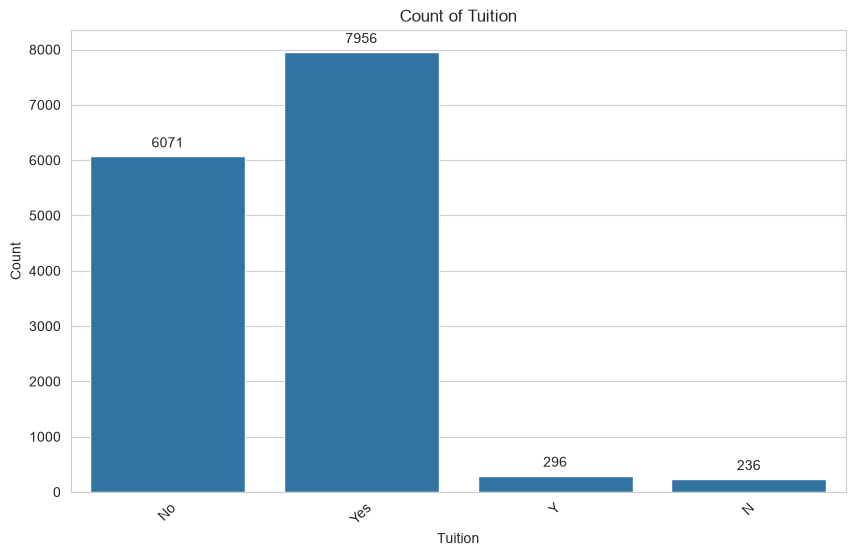

In [72]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for flat type with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='tuition', data=df)
plt.title('Count of Tuition')
plt.xlabel('Tuition')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

It has inconsistent labelling. "Yes" and "Y" appear to have the same meaning, as do "No" and "N". This is likely due to inconsistent data entry and will be standardised to "Yes" and "No" before further analysis.

In [73]:
df['tuition'] = df['tuition'].replace({'Y': 'Yes', 'N': 'No'})

# Check for missing values in the tuition column
print('Missing values in tuition:', df['tuition'].isna().sum())

# Verify the changes
print(df['tuition'].value_counts())

Missing values in tuition: 0
tuition
Yes    8252
No     6307
Name: count, dtype: int64


Next, I want to look at the frequency distribution of `CCA`.

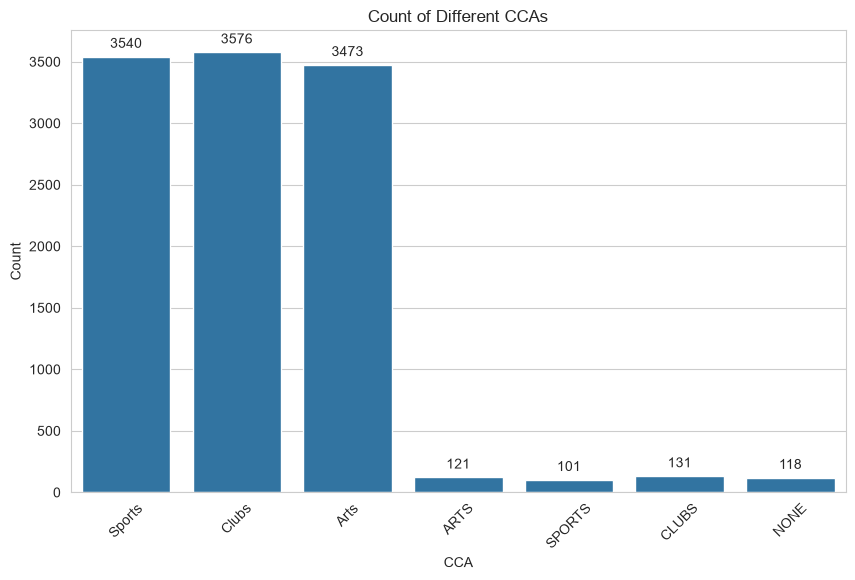

Missing values in CCA: 3499


In [74]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for flat type with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='CCA', data=df)
plt.title('Count of Different CCAs')
plt.xlabel('CCA')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

# Check for missing values in the tuition column
print('Missing values in CCA:', df['CCA'].isna().sum())

The CCA column has inconsistent capitalisation. "Sports" and "SPORTS", "Arts" and "ARTS", and "Clubs" and "CLUBS" appear to refer to the same CCA types, so they will be standardised to title case.

According to Ministry of Education (MOE), CCA participation is compulsory for secondary school students. However, the dataset contains 130 records labelled "NONE" and 3,607 missing values, which suggests some students may be exempted or their CCA was not recorded. As there is no information to indicate which CCA these students belong to, they cannot be assigned to an existing CCA category.

In [75]:
df['CCA'] = df['CCA'].fillna('Missing')

df.groupby('CCA').agg(
    mean_final_test=('final_test', 'mean'),
    mean_attendance=('attendance_rate', 'mean'),
    mean_hours_per_week=('hours_per_week', 'mean')
).round(2).reindex(['Missing', 'NONE', 'Arts', 'Clubs', 'Sports'])

,mean_final_test,mean_attendance,mean_hours_per_week
CCA,,,
Missing,76.75,94.56,9.52
NONE,76.84,95.10,9.51
Arts,64.10,92.96,10.64
Clubs,64.00,93.04,10.62
Sports,64.09,92.54,10.52



The missing group has a mean 'final_test' score of 76.8, almost identical to the "NONE" group (76.7) and noticeably higher than students in Sports, Clubs or Arts (around 64). Therefore, "NONE" and 3,607 missing values will be categorised as "No CCA".

In [76]:
df['CCA'] = df['CCA'].replace('Missing', 'None').fillna('None')
df['CCA'] = df['CCA'].str.title()

# Verify the changes
print(df['CCA'].value_counts())

CCA
Clubs     3707
Sports    3641
None      3617
Arts      3594
Name: count, dtype: int64


### Histogram

I want to look at the distribution of `final_test`. Since `final_test` is a continuous data, using Histogram is more suitable as compared to Bar Chart.

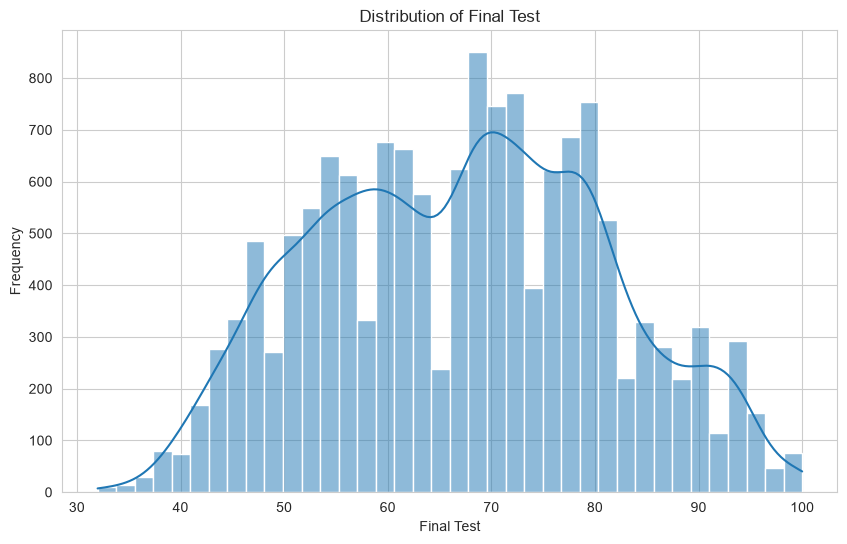

In [77]:
# Set the aesthetic style of the plots  
sns.set_style("whitegrid")  
  
# Histogram for resale price  
plt.figure(figsize=(10, 6))  
sns.histplot(df['final_test'], kde=True)  
plt.title('Distribution of Final Test')  
plt.xlabel('Final Test')  
plt.ylabel('Frequency')  
plt.show()

In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,14559.0,7779.935435,4584.869477,0.0,3800.5,7680.0,11728.5,15899.0
number_of_siblings,14559.0,0.888797,0.751925,0.0,0.0,1.0,1.0,2.0
final_test,14559.0,67.188474,13.976515,32.0,56.0,68.0,78.0,100.0
n_male,14559.0,13.858782,6.546491,0.0,10.0,14.0,18.0,31.0
n_female,14559.0,8.919569,6.659381,0.0,4.0,8.0,13.0,31.0
age,14559.0,15.501614,0.500015,15.0,15.0,16.0,16.0,16.0
hours_per_week,14559.0,10.322756,4.464052,0.0,7.0,9.0,14.0,20.0
attendance_rate,13890.0,93.283297,7.939237,40.0,92.0,95.0,97.0,100.0
sleep_hours,14559.0,7.847517,0.599577,4.0,8.0,8.0,8.0,8.0
class_size,14559.0,22.778350,4.234682,14.0,20.0,22.0,27.0,31.0


The distribution of 'final_test' is approximately symmetric, with test scores ranging from around 32 to 100. The mean score is 67 while the median is 68. As the mean is almost equal to the median, this suggests that there are no extreme scores at either end pulling the average up or down, and the mean is a fair representation of a typical student's score.

### Sleep and Wake Patterns

I plotted a line chart for 'sleep_time' because it follows a natural time order, which makes it easier to spot patterns in students' sleeping behaviour, such as sudden drops or peaks at certain times.

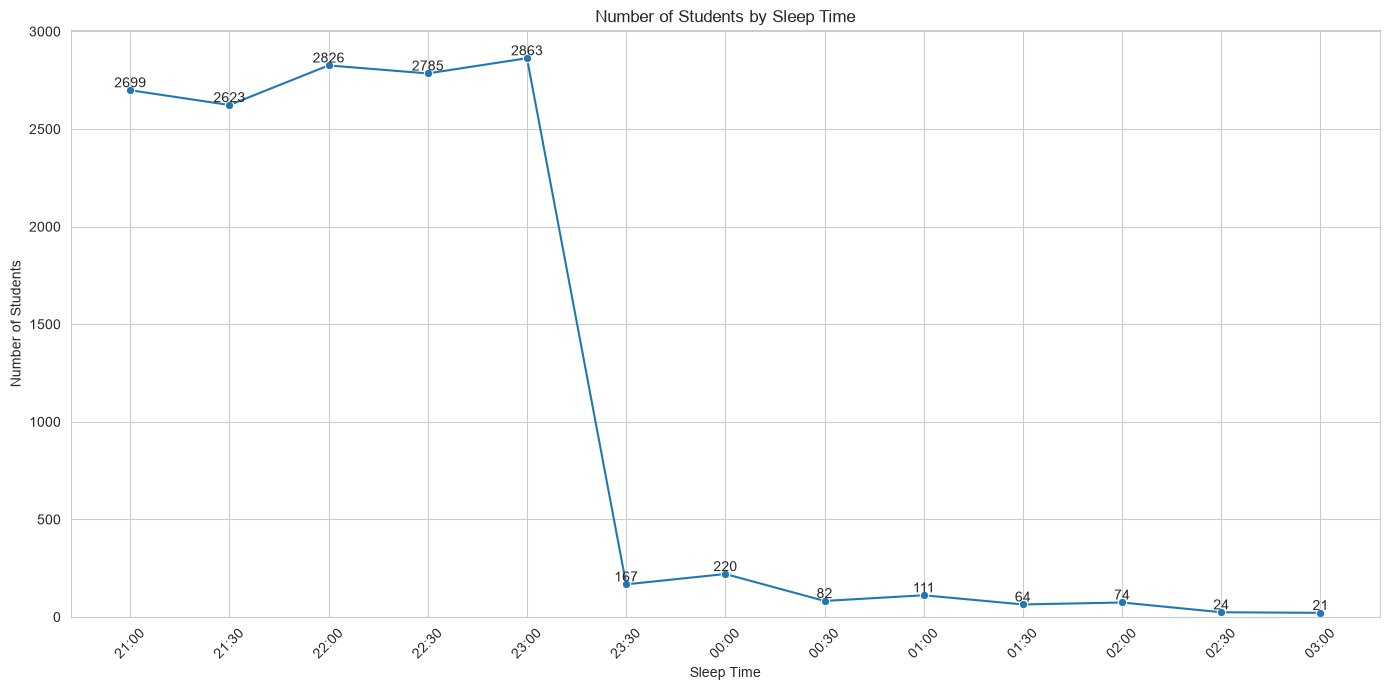

In [79]:
# Set Aesthetic Style
sns.set_style("whitegrid")

# Standardise format to HH:MM
df['sleep_time'] = pd.to_datetime(df['sleep_time'], format='%H:%M').dt.strftime('%H:%M')

# Count the Number of Students by Sleep Time
sleep_counts = df['sleep_time'].value_counts()

# Sort across midnight: times before 12:00 are treated as the next day
times = pd.to_datetime(sleep_counts.index, format='%H:%M')
minutes = times.hour * 60 + times.minute
minutes = minutes.where(times.hour >= 12, minutes + 24 * 60)
sleep_counts = sleep_counts.iloc[minutes.argsort()]

# Create the Line Chart
plt.figure(figsize=(14, 7))
line_plot = sns.lineplot(x=sleep_counts.index, y=sleep_counts.values, marker='o')

# Annotate the Data Points
for x, y in zip(sleep_counts.index, sleep_counts.values):
    plt.text(x, y, f'{y}', ha='center', va='bottom')

# Label the Chart
plt.title('Number of Students by Sleep Time')
plt.xlabel('Sleep Time')
plt.ylabel('Number of Students')
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Most students go to bed between 21:00 and 23:00, while a small number sleep between 23:30 and 03:00. Every student who sleeps by 23:00 gets exactly 8 hours of sleep, while late sleepers get between 4 and 7 hours. Among secondary school students in Singapore, late bedtimes are commonly linked to finishing homework or long hours spent on CCAs after school. Insufficient sleep may in turn affect their studies, as it can impair memory, reduce focus and lower their energy to learn.

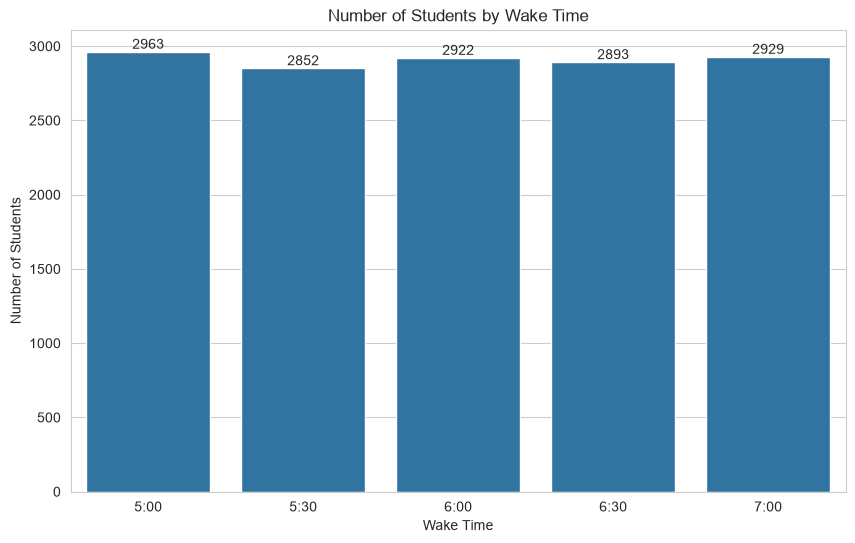

In [80]:
# Count students by wake time, sorted in time order
wake_counts = df['wake_time'].value_counts()
wake_counts = wake_counts.iloc[pd.to_datetime(wake_counts.index, format='%H:%M').argsort()]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=wake_counts.index, y=wake_counts.values)
ax.bar_label(ax.containers[0])
plt.title('Number of Students by Wake Time')
plt.xlabel('Wake Time')
plt.ylabel('Number of Students')
plt.show()

Wake times are spread fairly evenly between 5:00 and 7:00, with no single time dominating. Unlike bedtimes, wake times do not vary with how late students sleep, as they are set by when students need to leave for school. This is explained further by the crosstab below, which shows that wake time is fully determined by mode of transport.

In [81]:
pd.crosstab(df['mode_of_transport'], df['wake_time'])

wake_time,5:00,5:30,6:00,6:30,7:00
mode_of_transport,,,,,
private transport,0,0,2922,2893,0
public transport,2963,2852,0,0,0
walk,0,0,0,0,2929


Wake time is fully determined by mode of transport. Students who take public transport wake at 5:00 or 5:30, those who use private transport wake at 6:00 or 6:30, and those who walk wake at 7:00. This is consistent with secondary schools in Singapore typically starting around 7:30am, as students with longer commutes need to wake earlier. As a result, students who sleep late still have to wake up early for school, so they end up sleeping less.

## Bivariate Analysis

### Box Plot

I created a box plot to understand the distribution of `final_test` by `direct_admission` and identify outliers.

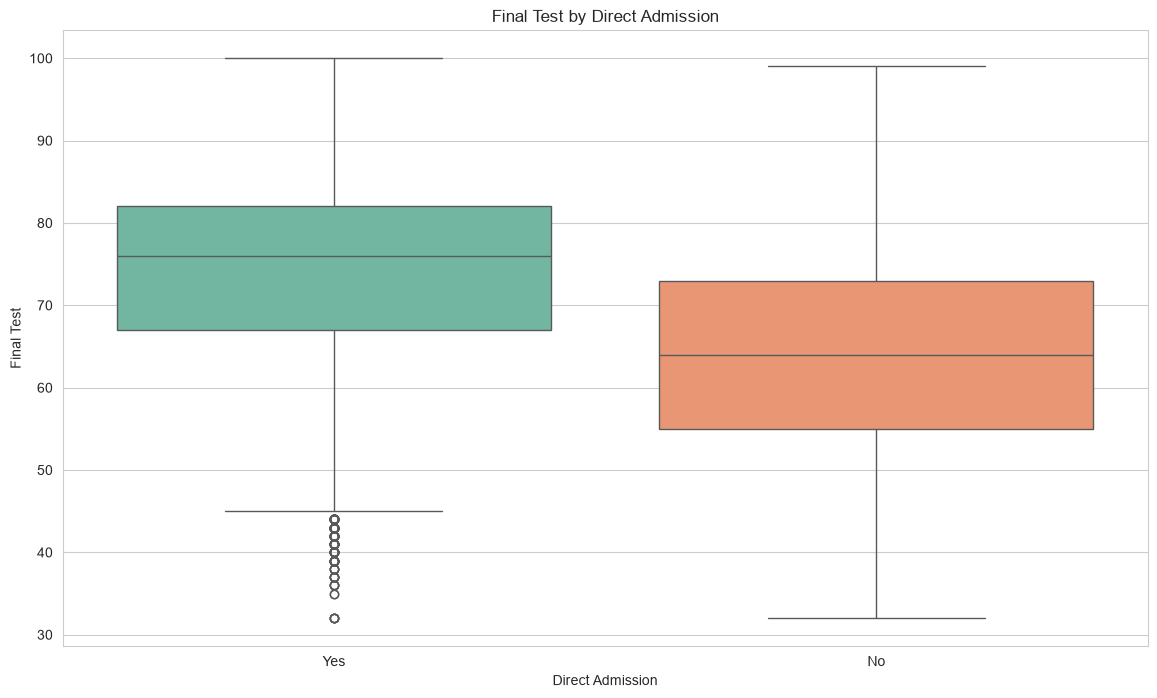

In [82]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='direct_admission', y='final_test', data=df, hue='direct_admission', palette='Set2')  
plt.title('Final Test by Direct Admission')
plt.xlabel('Direct Admission')
plt.ylabel('Final Test')
plt.xticks(rotation=0)
plt.show()

The overall distribution shows that students admitted through Direct School Admission (DSA) generally score higher in 'final_test' than those who were not. Both groups cover a similar full range of scores from around 32 to 100, but the bulk of DSA students sit noticeably higher on the scale.

The median score for DSA students is higher than non-DSA students. This is expected, as DSA students are selected based on their talents and achievements, and may already be stronger students before entering secondary school.

Looking at the interquartile range (IQR), DSA students have a slightly narrower spread than non-DSA students. This suggests that DSA students perform more consistently, while non-DSA students show more variation in their scores.

There is a presence of outliers in the DSA group, scoring much lower than their peers. These students are more likely to sleep late, have a lower attendance rate and spend fewer hours studying per week. This suggests that their poor performance may be linked to their study habits rather than their ability.

I created a box plot to understand the distribution of `final_test` by `CCA` and identify outliers.

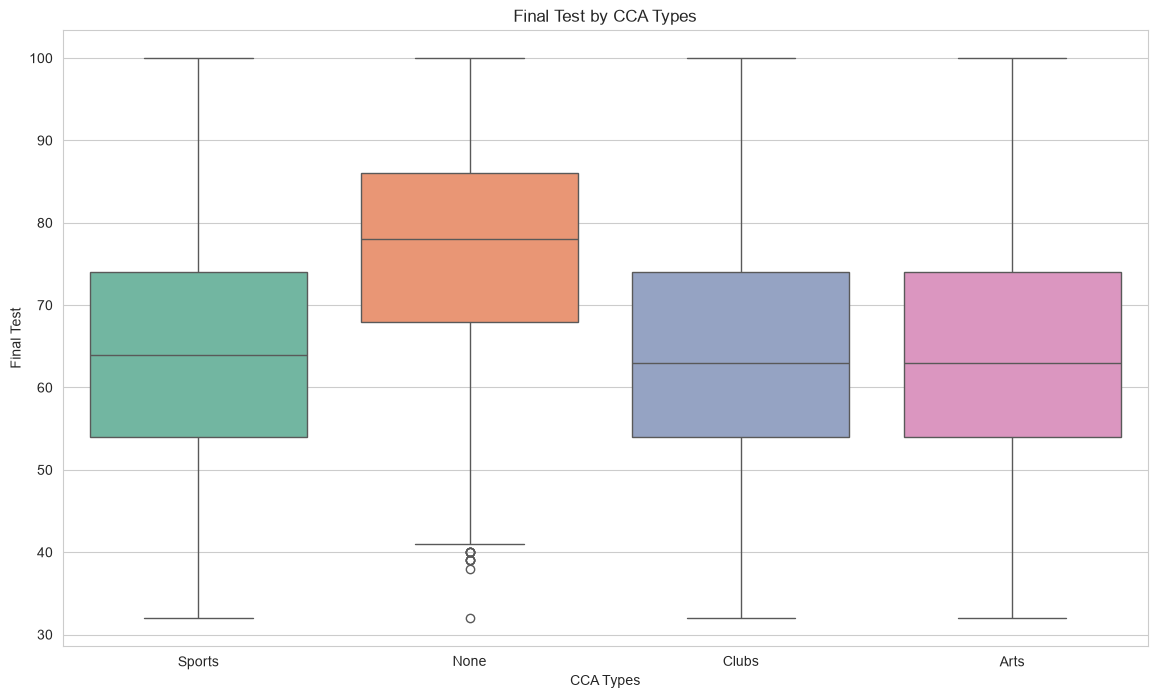

In [83]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='CCA', y='final_test', data=df, hue='CCA', palette='Set2')  
plt.title('Final Test by CCA Types')
plt.xlabel('CCA Types')
plt.ylabel('Final Test')
plt.xticks(rotation=0)
plt.show()

The overall distribution shows that students with no CCA score noticeably higher than students in Sports, Clubs or Arts. The three CCA groups have almost identical distributions, suggesting that the type of CCA itself makes little difference to test scores.

The median score for students with no CCA is higher than that of the Sports, Clubs and Arts groups. One possible explanation is that students without a CCA have more time available after school for studying.

Looking at the interquartile range (IQR), the Sports, Clubs and Arts groups share the same spread, while students with no CCA have a slightly narrower spread, indicating more consistent performance within that group.

There are a few outliers among students with no CCA who scored far below the rest of their group. Their poor performance may be linked to other factors such as study habits, sleep, learning ability or attendance rather than their CCA status.

I created a box plot to understand the distribution of `final_test` by `learning_style` and identify outliers.

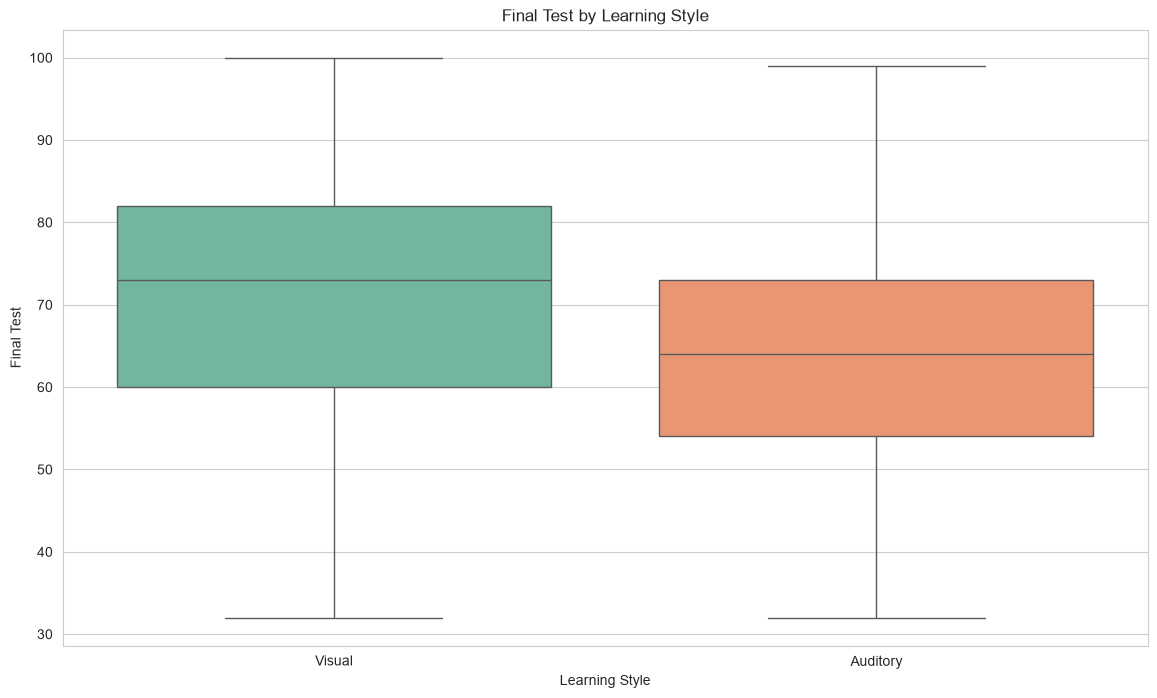

In [84]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='learning_style', y='final_test', data=df, hue='learning_style', palette='Set2')  
plt.title('Final Test by Learning Style')
plt.xlabel('Learning Style')
plt.ylabel('Final Test')
plt.xticks(rotation=0)
plt.show()

The overall distribution shows that visual learners generally score higher in 'final_test' than auditory learners, although both groups span a similar range of scores from around 32 to 100.

The median score for visual learners is higher than that of auditory learners. This suggests that learning style may be associated with test performance. One possible reason is that mathematics relies heavily on diagrams, graphs and written working to explain abstract concepts, which may make the subject easier to understand for visual learners.

Looking at the interquartile range (IQR), visual learners show a wider spread than auditory learners. This means that while visual learners tend to score higher, their performance is also more varied.

There are no outliers in either group, as all scores fall within the expected range for each learning style.

I created a box plot to understand the distribution of `final_test` by `gender` and identify outliers.

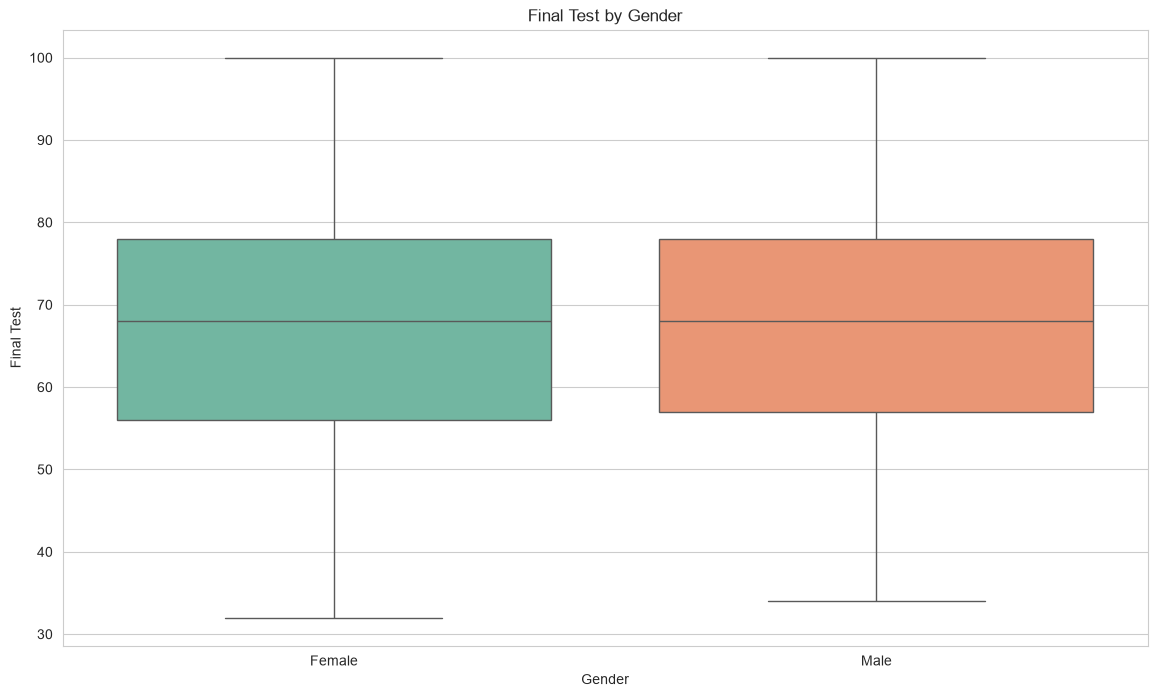

In [85]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='gender', y='final_test', data=df, hue='gender', palette='Set2')  
plt.title('Final Test by Gender')
plt.xlabel('Gender')
plt.ylabel('Final Test')
plt.xticks(rotation=0)
plt.show()

The distribution of `final_test` is almost identical for male and female students, with the same median and spread in both groups and no outliers. This suggests that gender has no meaningful relationship with test performance, which is tested formally below.

I created a box plot to understand the distribution of `final_test` by `tuition` and identify outliers.

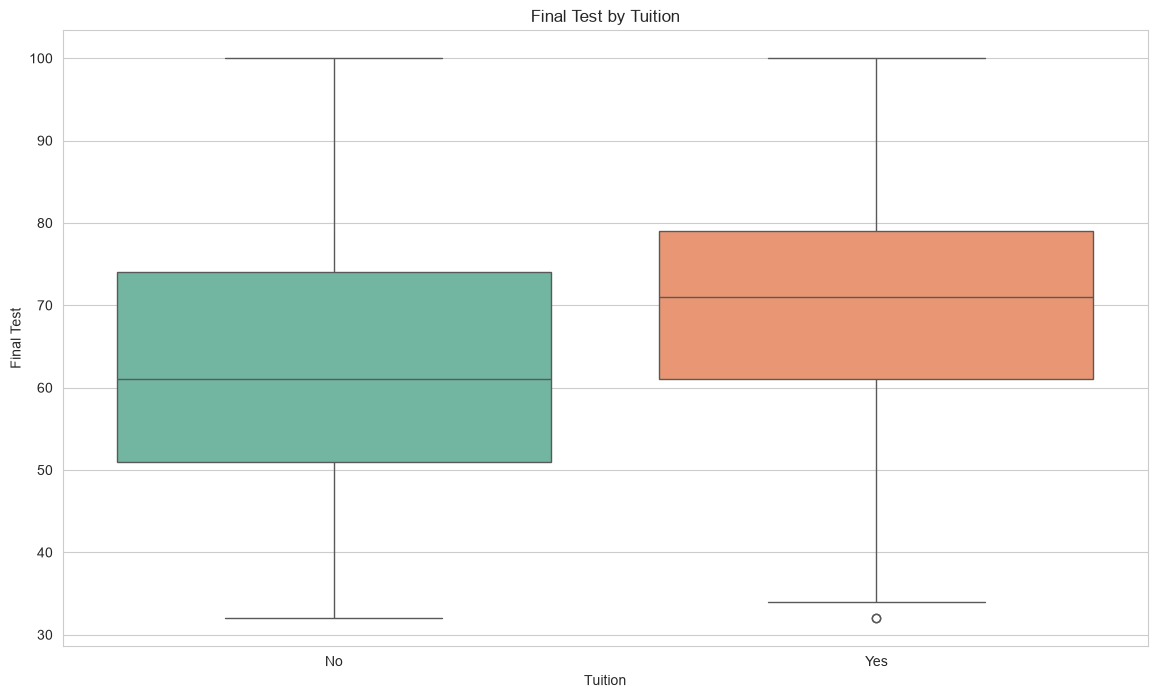

In [86]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='tuition', y='final_test', data=df, hue='tuition', palette='Set2')  
plt.title('Final Test by Tuition')
plt.xlabel('Tuition')
plt.ylabel('Final Test')
plt.xticks(rotation=0)
plt.show()

The overall distribution shows that students who take tuition generally score higher in 'final_test' than those who do not.

The median score for students with tuition is higher than students without tuition. This may be due to the additional practice and guidance that tuition provides outside of school. Although students who take tuition may also differ in other ways, such as having more family support.

Looking at the interquartile range (IQR), students without tuition show a wider spread than those with tuition. This suggests that students with tuition perform more consistently, while students without tuition show greater variation, ranging from weak to strong performers.

There are a small number of outliers in the tuition group, representing students who scored very low despite taking tuition. Their performance may be affected by other factors such as study habits, sleep or attendance.

I created a box plot to understand the distribution of `final_test` by `mode_of_transport` and identify outliers.

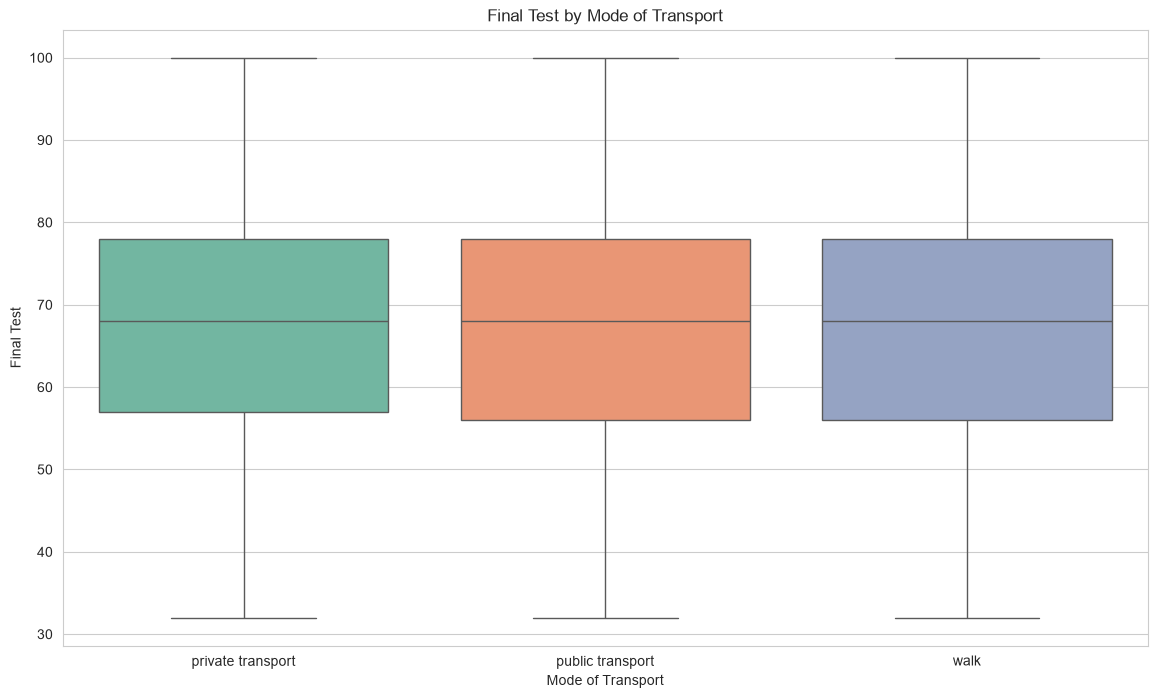

In [87]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='mode_of_transport', y='final_test', data=df, hue='mode_of_transport', palette='Set2')  
plt.title('Final Test by Mode of Transport')
plt.xlabel('Mode of Transport')
plt.ylabel('Final Test')
plt.xticks(rotation=0)
plt.show()

The distribution of `final_test` is almost identical across all three modes of transport, with the same median and spread in every group and no outliers. This suggests that mode of transport has no meaningful relationship with test performance, which is tested formally below.

I created a box plot to understand the distribution of `final_test` by `bag_color` and identify outliers.

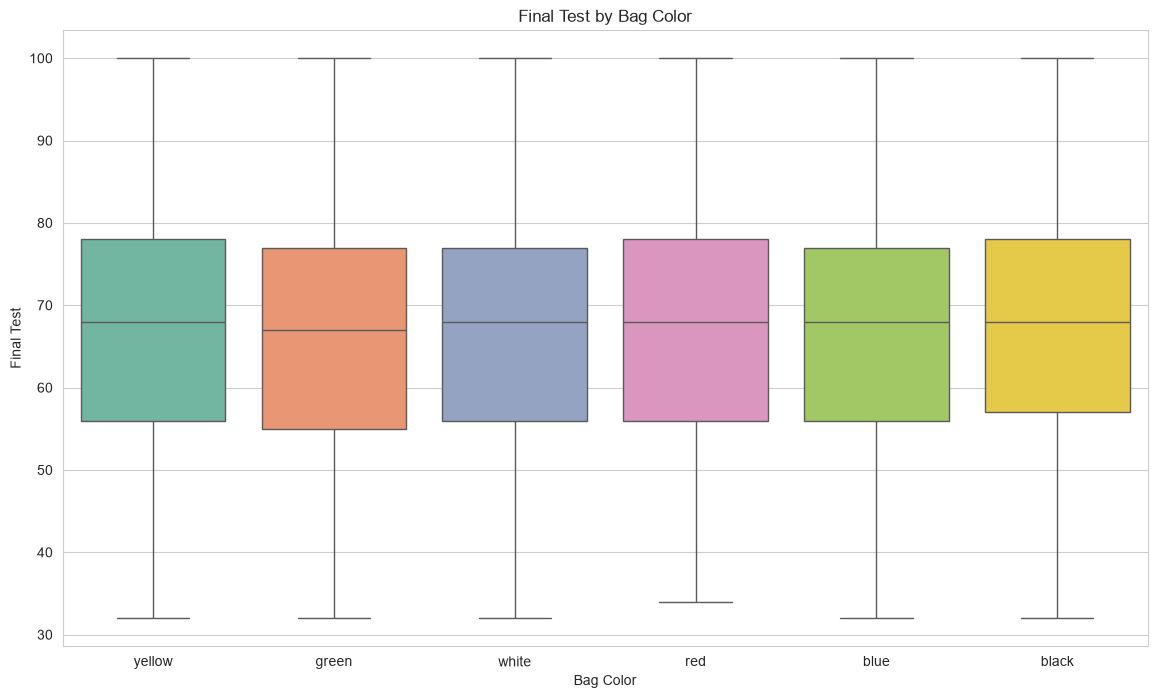

In [88]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='bag_color', y='final_test', data=df, hue='bag_color', palette='Set2')  
plt.title('Final Test by Bag Color')
plt.xlabel('Bag Color')
plt.ylabel('Final Test')
plt.xticks(rotation=0)
plt.show()

The distribution of `final_test` is almost identical for all six bag colours, with the same median and spread in both groups and no outliers. This suggests that gender has no meaningful relationship with test performance, which is tested formally below.

### Statistical Tests for Categorical Features

The box plots suggest that some categorical features are linked to `final_test`, but visual differences alone do not show whether they are statistically meaningful. To confirm this, I used non-parametric tests, which compare groups based on ranks rather than assuming a specific distribution:

- **Mann-Whitney U test** for features with two groups
- **Kruskal-Wallis test** for features with three or more groups

Although `final_test` is fairly close to a normal distribution, it is flatter than a typical bell curve, and the spread of scores differs between some groups, such as the CCA categories. Non-parametric tests are not affected by either issue, making them a safer choice.

As the dataset is large, even very small differences can be statistically significant. I therefore also calculated the effect size, which shows how large the difference actually is. For Mann-Whitney U, the rank-biserial correlation is used (around 0.1 is small, 0.3 medium and 0.5 large). For Kruskal-Wallis, epsilon-squared is used (around 0.01 is small, 0.08 medium and 0.26 large).

In [89]:
from scipy import stats

def test_categorical(df, feature, target='final_test'):
    """Run Mann-Whitney U or Kruskal-Wallis depending on the number of groups."""
    data = df.dropna(subset=[target])
    groups = [g[target].values for _, g in data.groupby(feature)]
    n, k = len(data), len(groups)

    if k == 2:
        u, p = stats.mannwhitneyu(groups[0], groups[1])
        effect = abs(1 - 2 * u / (len(groups[0]) * len(groups[1])))  # Rank-biserial correlation
        test = 'Mann-Whitney U'
    else:
        h, p = stats.kruskal(*groups)
        effect = max((h - k + 1) / (n - k), 0)  # Epsilon-squared
        test = 'Kruskal-Wallis'

    return {'feature': feature, 'test': test, 'groups': k,
            'p_value': p, 'effect_size': round(effect, 3),
            'significant': p < 0.05}

cat_features = ['direct_admission', 'learning_style', 'tuition', 'CCA',
                'gender', 'mode_of_transport', 'bag_color']

results = pd.DataFrame([test_categorical(df, f) for f in cat_features])
results['p_value'] = results['p_value'].apply(lambda p: '< 0.001' if p < 0.001 else round(p, 3))
results

,feature,test,groups,p_value,effect_size,significant
0,direct_admission,Mann-Whitney U,2,< 0.001,0.344,True
1,learning_style,Mann-Whitney U,2,< 0.001,0.319,True
2,tuition,Mann-Whitney U,2,< 0.001,0.311,True
3,CCA,Kruskal-Wallis,4,< 0.001,0.152,True
4,gender,Mann-Whitney U,2,0.139,0.014,False
5,mode_of_transport,Kruskal-Wallis,3,0.917,0.000,False
6,bag_color,Kruskal-Wallis,6,0.192,0.000,False


The test results confirm the patterns seen in the box plots.

`direct_admission`, `learning_style`, `tuition` and `CCA` all show a statistically significant difference in `final_test` (p < 0.001), with medium effect sizes. This means the differences between their groups are both real and large enough to be meaningful, so these features are likely to be useful predictors.

`gender`, `mode_of_transport` and `bag_color` show no significant difference (p > 0.05) and effect sizes close to zero. This supports dropping them, as students score about the same regardless of these features.

In [90]:
# Compare with parametric tests (t-test and ANOVA) as a robustness check
data = df.dropna(subset=['final_test'])

for f in cat_features:
    groups = [g['final_test'].values for _, g in data.groupby(f)]
    if len(groups) == 2:
        p_param = stats.ttest_ind(*groups, equal_var=False).pvalue
    else:
        p_param = stats.f_oneway(*groups).pvalue
    print(f'{f}: parametric p = {p_param:.3g}')

direct_admission: parametric p = 1.05e-184
learning_style: parametric p = 9.33e-240
tuition: parametric p = 2.87e-233
CCA: parametric p = 0
gender: parametric p = 0.178
mode_of_transport: parametric p = 0.839
bag_color: parametric p = 0.212


As a robustness check, parametric tests (t-test and ANOVA) were also run. They gave the same conclusions for every feature, confirming that the results do not depend on the choice of test.

In [91]:
# Check whether the CCA type matters, excluding students with no CCA
has_cca = df[(df['CCA'] != 'None') & df['final_test'].notna()]
stat, p = stats.kruskal(*[g['final_test'] for _, g in has_cca.groupby('CCA')])
print(f'Kruskal-Wallis (Sports, Clubs, Arts only): p = {p:.3f}')

Kruskal-Wallis (Sports, Clubs, Arts only): p = 0.772


The Kruskal-Wallis test only shows that at least one CCA group differs from the others. When students with no CCA are excluded, there is no significant difference between Sports, Clubs and Arts (p = 0.77). This confirms that the difference comes from whether a student has a CCA, not the type of CCA.

### Scatter Plot

I create scatter plot to visualise relationship between two continuous variables, identify correlations, trends, and patterns in the data.

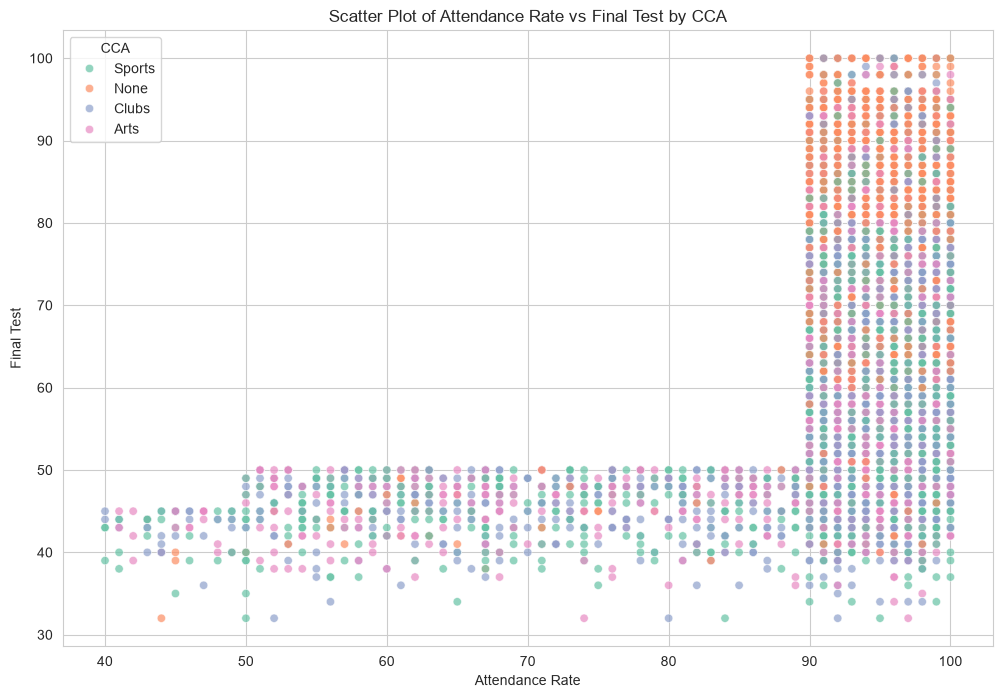

In [92]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Scatter plot for floor area vs resale price with color encoding for flat type
plt.figure(figsize=(12, 8))
sns.scatterplot(x='attendance_rate', y='final_test', hue='CCA', data=df, palette='Set2', alpha=0.7)
plt.title('Scatter Plot of Attendance Rate vs Final Test by CCA')
plt.xlabel('Attendance Rate')
plt.ylabel('Final Test')
plt.legend(title='CCA')
plt.show()

The relationship between `attendance_rate` and `final_test` is non-linear. Students with attendance below 90% all scored 50 or below, while students with attendance of 90% and above achieved the full range of scores from around 32 to 100. Within each group, higher attendance does not lead to higher scores, suggesting that attendance acts as a minimum requirement for good performance rather than a steady predictor.

## Outlier Analysis

To check for outliers consistently, I applied the IQR rule to every numerical feature. A value is flagged as an outlier if it falls below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR. For each feature, I counted the outliers and compared the average `final_test` of outliers against the rest, to see whether the outliers are noise or carry useful information.

In [93]:
num_features = ['number_of_siblings', 'hours_per_week', 'attendance_rate',
                'class_size', 'sleep_hours', 'final_test']

outlier_summary = []
for col in num_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (df[col] < lower) | (df[col] > upper)

    outlier_summary.append({
        'feature': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'n_outliers': is_outlier.sum(),
        'outlier_%': round(is_outlier.sum() / df[col].notna().sum() * 100, 2),
        'mean_final_test_outliers': round(df.loc[is_outlier, 'final_test'].mean(), 1),
        'mean_final_test_others': round(df.loc[~is_outlier & df[col].notna(), 'final_test'].mean(), 1)
    })

pd.DataFrame(outlier_summary)

,feature,lower_bound,upper_bound,n_outliers,outlier_%,mean_final_test_outliers,mean_final_test_others
0,number_of_siblings,-1.5,2.5,0,0.00,NaN,67.2
1,hours_per_week,-3.5,24.5,0,0.00,NaN,67.2
2,attendance_rate,84.5,104.5,770,5.54,45.2,68.5
3,class_size,9.5,37.5,0,0.00,NaN,67.2
4,sleep_hours,8.0,8.0,1166,8.01,53.5,68.4
5,final_test,23.0,111.0,0,0.00,NaN,67.2


`number_of_siblings`, `hours_per_week`, `class_size` and `final_test` have no outliers, as all their values fall within the expected range.

`attendance_rate` has 793 outliers (about 5.5%), all with attendance below 85%. These students score much lower on average (45.2 compared to 68.5), which matches the threshold pattern seen in the scatter plot. The outliers are therefore genuine and informative rather than errors, and removing them would discard an important signal.

`sleep_hours` has 1,200 values flagged as outliers, but this is caused by a limitation of the IQR rule rather than true outliers. As most students sleep exactly 8 hours, the first and third quartiles are both 8, giving an IQR of zero. Every value other than 8 is therefore flagged, even though 4 to 7 hours of sleep are realistic. These students also score lower on average (53.5 compared to 68.4), so the values are meaningful.

As none of the flagged values are data errors, and those flagged carry useful information about performance, all outliers will be kept as they are.

## Correlation Analysis

### Heatmap

For this correlation analysis, Spearman rank correlation is used instead of Pearson correlation. Several variables, such as `number_of_siblings` and `sleep_hours`, only take a small number of ordered values and behave more like ordinal data than continuous measurements. 

In addition, some relationships, such as between `attendance_rate` and `final_test`, are not linear. Spearman correlation is better suited to this data, as it works on ranks and measures whether one variable consistently increases or decreases with another, without assuming a straight-line relationship or normally distributed data.

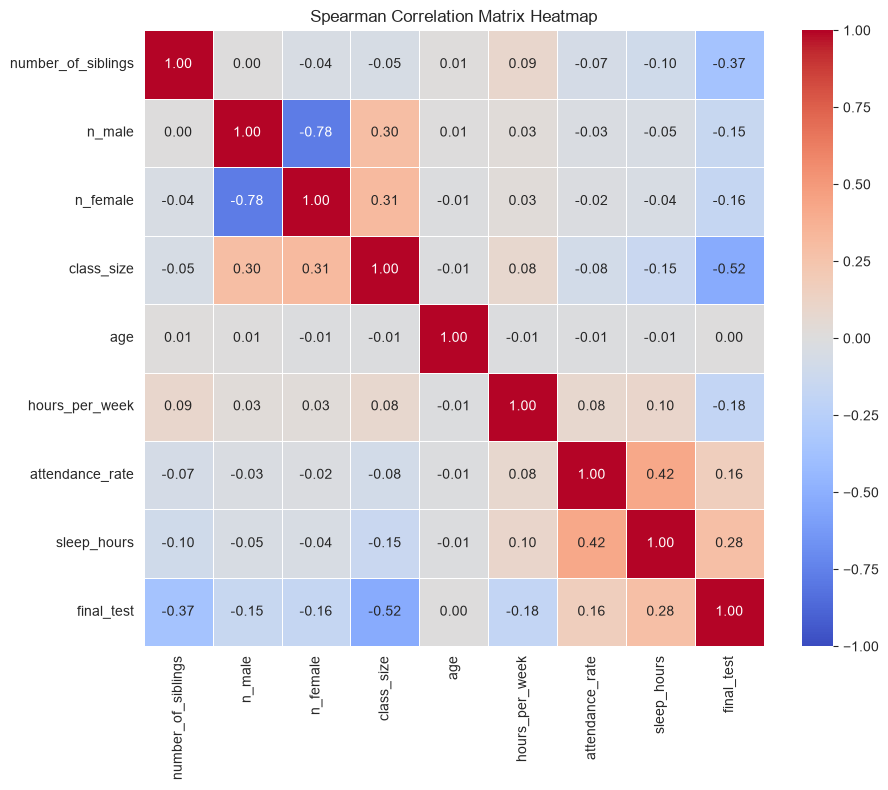

In [94]:
# Select relevant columns for correlation analysis
spearman_vars = df[['number_of_siblings', 'n_male', 'n_female', 'class_size', 'age', 'hours_per_week', 'attendance_rate', 'sleep_hours', 'final_test']]

# Compute the Spearman correlation matrix
spearman_corr = spearman_vars.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Spearman Correlation Matrix Heatmap')
plt.show()

1. There is a moderate negative monotonic correlation between 'number_of_siblings' and 'final_test'. Students with more siblings tend to score lower, which may be because parental attention and resources are shared among more children.

2. There is a weak negative monotonic correlation between both 'n_male' and 'n_female' and 'final_test'. Students in classes with more boys or more girls tend to score slightly lower, but neither relationship is strong on its own. This is because each column only captures part of the class, and neither reflects the overall class size by itself. Combining them into a single 'class_size' feature would therefore better capture the effect of class size on 'final_test'.

3. There is no correlation between 'age' and 'final_test'. 'age' provides no useful information for predicting 'final_test', it should be removed to avoid adding noise to the model.

4. There is a weak negative monotonic correlation between 'hours_per_week' and 'final_test'. Students who spend more hours studying tend to score slightly lower, which may be because weaker students need to spend more time studying to keep up with their peers.

5. There is a weak positive monotonic correlation between 'attendance_rate' and 'final_test'. Students with higher attendance tend to score higher, but the correlation is not strong.

6. There is a weak positive monotonic correlation between 'sleep_hours' and 'final_test'. Students who sleep more tend to score higher, but the relationship is not strong.

7. There is also a moderate positive monotonic correlation between 'attendance_rate' and 'sleep_hours'. Students who sleep more tend to have better attendance. As the two features are related, this should be checked for multicollinearity before modelling.

## Multicollinearity Check

The heatmap shows a moderate correlation between `attendance_rate` and `sleep_hours`. To check whether this overlap is strong enough to cause problems in a linear regression model, I calculated the Variance Inflation Factor (VIF) for the numerical features. A VIF above 5 is commonly used as a sign of concerning multicollinearity.

In [95]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_features = ['number_of_siblings', 'class_size', 'hours_per_week', 'attendance_rate', 'sleep_hours']

# VIF cannot handle missing values, so rows with a missing attendance_rate are skipped
X = add_constant(df[vif_features].dropna())

vif = pd.DataFrame({
    'feature': vif_features,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
}).round(2)

vif

,feature,VIF
0,number_of_siblings,1.04
1,class_size,1.05
2,hours_per_week,1.05
3,attendance_rate,4.72
4,sleep_hours,4.66


Most features have a VIF close to 1, showing little overlap with each other. `attendance_rate` and `sleep_hours` have a VIF of around 4.7, which confirms they are related, as students who sleep more tend to have better attendance. However, this is below the threshold of 5, so both features will be kept, although their coefficients in a linear regression model should be interpreted with caution.

## Summary: From EDA to Modelling

### Data Quality Issues

| Issue | Records affected | Action taken | Modelling implication |
|---|---|---|---|
| Duplicate students | 900 | Missing values recovered from the duplicate row, then duplicates removed | Prevents the same student from appearing in both training and test sets |
| Invalid ages (5, 6, -5, -4) | 451 | 5 and 6 corrected to 15 and 16; negative ages imputed with the mode (16) | `age` is clean, but is dropped anyway as it has no relationship with `final_test` |
| Inconsistent `tuition` labels ("Y", "N") | 588 | Standardised to "Yes" and "No" | Avoids splitting one category into two during encoding |
| Inconsistent `CCA` capitalisation | 379 | Standardised to title case | Avoids duplicate categories during encoding |
| Missing `CCA` | 3,607 | Combined with "NONE" into "No CCA", as both groups have a very similar profile | Keeps these students in the data with a meaningful category |
| Missing `final_test` | 441 (after recovery) | Rows dropped | Avoids training and evaluating the model on made-up target values |
| Missing `attendance_rate` | 669 (after recovery) | To be imputed with the median inside the preprocessing pipeline | Median is calculated from the training set only, preventing data leakage |
| Identifier columns (`index`, `student_id`) | 100% unique | Dropped | Prevents meaningless one-hot columns and removes any leakage risk |
| Outliers in `attendance_rate` | 793 | Kept | Low attendance is linked to much lower scores, so these values are informative |

### Feature Decisions

| Feature | Decision | Reason |
|---|---|---|
| `direct_admission`, `learning_style`, `tuition` | Keep, encode as binary | Significant difference in `final_test` with medium effect sizes |
| `CCA` | Keep, one-hot encode | Significant difference driven by having a CCA or not |
| `number_of_siblings`, `hours_per_week`, `attendance_rate` | Keep, scale | Related to `final_test` in the correlation analysis |
| `class_size` (engineered) | Keep, scale | Stronger correlation with `final_test` than `n_male` or `n_female` on their own |
| `sleep_hours` (engineered) | Keep, scale | Captures the useful information from `sleep_time` and `wake_time` in one feature |
| `n_male`, `n_female` | Drop | Replaced by `class_size`, and keeping all three would cause multicollinearity |
| `sleep_time`, `wake_time` | Drop | Replaced by `sleep_hours` |
| `gender`, `mode_of_transport`, `bag_color` | Drop | No significant difference in `final_test` |
| `age` | Drop | No correlation with `final_test` |

### Key Insights for Modelling

1. **Some relationships are non-linear.** `attendance_rate` acts as a threshold, with students below about 90% all scoring 50 or below. Tree-based models may capture this better than linear regression.
2. **`attendance_rate` and `sleep_hours` are related** (VIF around 4.7). This is below the threshold of 5, so both are kept, but their linear regression coefficients should be interpreted with caution.
3. **The strongest predictors** appear to be `class_size`, `number_of_siblings`, `direct_admission`, `learning_style` and `tuition`, based on the correlation analysis and statistical tests.